# 06 — Opportunities and destinations

Aligned with `configs/defaults.yaml` `accessibility.opportunities`:

- **jobs** — LEHD **LODES** WAC (workplace counts). Expect `data/raw/external/lodes/ca_wac_*_JT00_*.csv.gz` from `python scripts/download_data.py --sources lodes`.
- **hospitals**, **groceries**, **schools** — OSM features inside the study **bbox** via `osmnx.features_from_bbox` (separate tag sets; documented in code).

**Exports:** `artifacts/tables/` (`eda__<desc>__<YYYY-MM-DD>.csv`) and `artifacts/figures/` (dpi=200). Add index rows yourself in `context/structure.md` when you run.

**Prior:** [`05_osm_pedestrian_network.ipynb`](05_osm_pedestrian_network.ipynb)  
**Next:** [`07_cross_source_sanity_joins.ipynb`](07_cross_source_sanity_joins.ipynb)


In [3]:
pip install osmnx

   ---------------------------------------- 0.0/104.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/104.4 kB ? eta -:--:--
   --- ------------------------------------ 10.2/104.4 kB ? eta -:--:--
   ----------- --------------------------- 30.7/104.4 kB 435.7 kB/s eta 0:00:01
   ------------------------------ -------- 81.9/104.4 kB 651.6 kB/s eta 0:00:01
   -------------------------------------- 104.4/104.4 kB 667.8 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
from __future__ import annotations

import warnings
from datetime import date
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandas as pd
import yaml
from IPython.display import Markdown, display
from shapely.geometry import box

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")


def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "configs" / "san_diego.yaml").exists():
            return d
    raise FileNotFoundError("Could not find configs/san_diego.yaml (cd to repo root).")


def configure_osmnx(cfg: dict) -> None:
    """Match scripts/download_data.py: integer Overpass timeout + optional mirror."""
    osm = cfg.get("osm") or {}
    ox.settings.requests_timeout = int(osm.get("requests_timeout_seconds", 900))
    if url := osm.get("overpass_url"):
        ox.settings.overpass_url = str(url).rstrip("/")
    if "overpass_rate_limit" in osm:
        ox.settings.overpass_rate_limit = bool(osm["overpass_rate_limit"])
    ox.settings.log_console = True


def gdf_to_csv_rows(gdf: gpd.GeoDataFrame, max_rows: int | None = None) -> pd.DataFrame:
    """Tabular export: centroid lon/lat + key OSM columns; drop geometry."""
    if gdf is None or gdf.empty:
        return pd.DataFrame()
    out = gdf.reset_index(drop=False)
    if "geometry" not in out.columns:
        return out
    geom = out["geometry"]
    out["lon"] = geom.centroid.x
    out["lat"] = geom.centroid.y
    out = out.drop(columns=["geometry"])
    if max_rows is not None and len(out) > max_rows:
        out = out.iloc[:max_rows].copy()
        out.attrs["truncated_note"] = f"truncated_to_{max_rows}_rows"
    return out


REPO_ROOT = find_repo_root()
with open(REPO_ROOT / "configs" / "defaults.yaml") as f:
    config = yaml.safe_load(f)
with open(REPO_ROOT / "configs" / "san_diego.yaml") as f:
    config.update(yaml.safe_load(f))

bbox = config["bbox"]  # [min_lon, min_lat, max_lon, max_lat]
min_lon, min_lat, max_lon, max_lat = bbox
BBOX_OX = (min_lon, min_lat, max_lon, max_lat)  # osmnx: left, bottom, right, top

census_cfg = config.get("census", {})
state_fips = str(census_cfg.get("state_fips", config.get("state_fips", "06"))).zfill(2)
county_fips = str(census_cfg.get("county_fips", config.get("county_fips", "073"))).zfill(3)
COUNTY_GEO_PREFIX = state_fips + county_fips  # "06073" for San Diego County blocks
acs_year = int(census_cfg.get("acs_year", 2023))

OPPORTUNITIES = list(config.get("accessibility", {}).get("opportunities", []))

TODAY = date.today().isoformat()
ART_TABLES = REPO_ROOT / "artifacts" / "tables"
ART_FIG = REPO_ROOT / "artifacts" / "figures"
ART_TABLES.mkdir(parents=True, exist_ok=True)
ART_FIG.mkdir(parents=True, exist_ok=True)

LODES_DIR = REPO_ROOT / "data" / "raw" / "external" / "lodes"
LODES_GLOB = sorted(LODES_DIR.glob("ca_wac_*_JT00_*.csv.gz"))

print(f"REPO_ROOT={REPO_ROOT}")
print(f"opportunities from config: {OPPORTUNITIES}")
print(f"bbox (osmnx order next line): {BBOX_OX}")
print(f"LODES files found: {len(LODES_GLOB)}")


REPO_ROOT=C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity
opportunities from config: ['jobs', 'hospitals', 'groceries', 'schools']
bbox (osmnx order next line): (-117.28, 32.53, -116.93, 33.11)
LODES files found: 0


## LODES WAC (jobs) — San Diego County

Uses block-level `w_geocode`; aggregates to **tract** (first 11 digits). Primary job total column: **`C000`** when present (LEHD WAC); falls back to the first numeric column starting with `C` after `w_geocode`.


In [5]:
def pick_jobs_column(df: pd.DataFrame) -> str:
    if "C000" in df.columns:
        return "C000"
    candidates = [c for c in df.columns if c != "w_geocode" and len(c) >= 2 and c[0] == "C" and c[1:].isdigit()]
    if candidates:
        return candidates[0]
    raise ValueError("Could not infer LODES jobs count column (expected C000 or C###).")


lodes_paths_written: list[str] = []

if "jobs" not in OPPORTUNITIES:
    display(Markdown("_Skipping LODES: `jobs` not in `accessibility.opportunities`._"))
elif not LODES_GLOB:
    msg = (
        f"No `ca_wac_*_JT00_*.csv.gz` under {LODES_DIR}. "
        "Run: `python scripts/download_data.py --config configs/san_diego.yaml --sources lodes`"
    )
    display(Markdown(f"_{msg}_"))
    st = pd.DataFrame([{"status": "file_not_found", "detail": msg}])
    p = ART_TABLES / f"eda__lodes_wac_run_status__{TODAY}.csv"
    st.to_csv(p, index=False)
    lodes_paths_written.append(str(p.relative_to(REPO_ROOT)))
else:
    lodes_path = LODES_GLOB[-1]
    wac = pd.read_csv(lodes_path, dtype={"w_geocode": str}, low_memory=False)
    wac["w_geocode"] = wac["w_geocode"].astype(str).str.zfill(15)
    job_col = pick_jobs_column(wac)
    wac[job_col] = pd.to_numeric(wac[job_col], errors="coerce").fillna(0).astype(int)

    sd = wac[wac["w_geocode"].str.startswith(COUNTY_GEO_PREFIX)].copy()
    sd["GEOID"] = sd["w_geocode"].str[:11]

    tract_jobs = (
        sd.groupby("GEOID", as_index=False)
        .agg(n_census_blocks=("w_geocode", "count"), lodes_jobs=(job_col, "sum"))
    )

    summary = pd.DataFrame(
        [
            {
                "lodes_file": lodes_path.name,
                "job_column_used": job_col,
                "n_blocks_ca_file": len(wac),
                "n_blocks_sd_county": len(sd),
                "total_jobs_sd_county": int(sd[job_col].sum()),
                "n_tracts_with_jobs": len(tract_jobs),
            }
        ]
    )

    p_sum = ART_TABLES / f"eda__lodes_wac_sd_summary__{TODAY}.csv"
    summary.to_csv(p_sum, index=False)
    lodes_paths_written.append(str(p_sum.relative_to(REPO_ROOT)))

    p_tr = ART_TABLES / f"eda__lodes_wac_sd_tract_jobs__{TODAY}.csv"
    tract_jobs.sort_values("GEOID").to_csv(p_tr, index=False)
    lodes_paths_written.append(str(p_tr.relative_to(REPO_ROOT)))

    display(Markdown("### LODES (SD county) summary"))
    display(summary)
    print("Written:", "\n  ".join(lodes_paths_written))


_No `ca_wac_*_JT00_*.csv.gz` under C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity\data\raw\external\lodes. Run: `python scripts/download_data.py --config configs/san_diego.yaml --sources lodes`_

## OSM destinations (per category)

Tag sets are **union** queries (see OSMnx docs). Adjust dictionaries if you need stricter definitions.


In [6]:
OSM_QUERIES: dict[str, dict] = {
    "hospitals": {
        "amenity": ["hospital", "clinic"],
        "healthcare": ["hospital"],
    },
    "groceries": {
        "shop": ["supermarket", "grocery", "convenience", "greengrocer", "bakery"],
        "amenity": ["marketplace"],
    },
    "schools": {
        "amenity": ["school", "kindergarten", "college", "university"],
    },
}

configure_osmnx(config)

poi_tables: dict[str, gpd.GeoDataFrame] = {}
poi_status_rows: list[dict] = []

for key, tags in OSM_QUERIES.items():
    if key not in OPPORTUNITIES:
        display(Markdown(f"_Skipping OSM `{key}`: not in config opportunities._"))
        continue
    try:
        gdf = ox.features_from_bbox(BBOX_OX, tags)
        gdf = gdf[gdf.geometry.notna()].copy()
        gdf["opportunity_category"] = key
        poi_tables[key] = gdf
        poi_status_rows.append(
            {
                "category": key,
                "status": "ok",
                "n_features": len(gdf),
                "error": "",
            }
        )
        print(f"OSM {key}: {len(gdf)} features")
    except Exception as e:
        poi_tables[key] = gpd.GeoDataFrame()
        poi_status_rows.append({"category": key, "status": "error", "n_features": 0, "error": str(e)})
        print(f"OSM {key} FAILED: {e}")

status_df = pd.DataFrame(poi_status_rows)
if not status_df.empty:
    p_st = ART_TABLES / f"eda__osm_destinations_fetch_status__{TODAY}.csv"
    status_df.to_csv(p_st, index=False)
    print(f"Saved: {p_st.relative_to(REPO_ROOT)}")

for key, gdf in poi_tables.items():
    tbl = gdf_to_csv_rows(gdf)
    p = ART_TABLES / f"eda__osm_destinations_{key}__{TODAY}.csv"
    tbl.to_csv(p, index=False)
    print(f"Saved: {p.relative_to(REPO_ROOT)}  (rows={len(tbl)})")


OSM hospitals: 143 features
OSM groceries: 886 features
OSM schools: 1000 features
Saved: artifacts\tables\eda__osm_destinations_fetch_status__2026-03-29.csv


C:\Users\sardo\AppData\Local\Temp\ipykernel_12208\4017730482.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  out["lon"] = geom.centroid.x
C:\Users\sardo\AppData\Local\Temp\ipykernel_12208\4017730482.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  out["lat"] = geom.centroid.y
C:\Users\sardo\AppData\Local\Temp\ipykernel_12208\4017730482.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  out["lon"] = geom.centroid.x
C:\Users\sardo\AppData\Local\Temp\ipykernel_12208\4017730482.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely

Saved: artifacts\tables\eda__osm_destinations_hospitals__2026-03-29.csv  (rows=143)
Saved: artifacts\tables\eda__osm_destinations_groceries__2026-03-29.csv  (rows=886)
Saved: artifacts\tables\eda__osm_destinations_schools__2026-03-29.csv  (rows=1000)


## Tract counts for OSM points (centroid in tract)


In [7]:
tiger_dir = REPO_ROOT / "data" / "raw" / "census" / f"tl_{acs_year}_{state_fips}_tract"
shp = tiger_dir / f"tl_{acs_year}_{state_fips}_tract.shp"
if not shp.exists():
    raise FileNotFoundError(f"Missing TIGER tracts: {shp}")

tracts_sd = gpd.read_file(shp)
tracts_sd = tracts_sd[
    (tracts_sd["STATEFP"].astype(str).str.zfill(2) == state_fips)
    & (tracts_sd["COUNTYFP"].astype(str).str.zfill(3) == county_fips)
].copy()
tracts_sd["GEOID"] = tracts_sd["GEOID"].astype(str)
tract_geoms = tracts_sd[["GEOID", "geometry"]].copy()

study_poly = box(min_lon, min_lat, max_lon, max_lat)
tracts_sd["intersects_study_bbox"] = tracts_sd.geometry.intersects(study_poly)
bbox_gdf = gpd.GeoDataFrame(geometry=[study_poly], crs="EPSG:4326")

wide = tracts_sd[["GEOID", "intersects_study_bbox"]].drop_duplicates("GEOID")
for key, gdf in poi_tables.items():
    col = f"n_osm_{key}"
    if gdf is None or gdf.empty:
        wide[col] = 0
        continue
    pts = gdf.copy()
    if pts.crs is None:
        pts = pts.set_crs(4326)
    pts = pts.to_crs(tract_geoms.crs)
    cent = gpd.GeoDataFrame(geometry=pts.geometry.centroid, crs=pts.crs)
    sj = gpd.sjoin(cent, tract_geoms, how="left", predicate="within")
    counts = sj.dropna(subset=["GEOID"]).groupby("GEOID").size().rename(col)
    wide = wide.merge(counts.reset_index(), on="GEOID", how="left")
    wide[col] = wide[col].fillna(0).astype(int)

p_tc = ART_TABLES / f"eda__tract_osm_destination_counts__{TODAY}.csv"
wide.sort_values("GEOID").to_csv(p_tc, index=False)
print(f"Saved: {p_tc.relative_to(REPO_ROOT)}")


Saved: artifacts\tables\eda__tract_osm_destination_counts__2026-03-29.csv


C:\Users\sardo\AppData\Local\Temp\ipykernel_12208\717529492.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cent = gpd.GeoDataFrame(geometry=pts.geometry.centroid, crs=pts.crs)
C:\Users\sardo\AppData\Local\Temp\ipykernel_12208\717529492.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cent = gpd.GeoDataFrame(geometry=pts.geometry.centroid, crs=pts.crs)
C:\Users\sardo\AppData\Local\Temp\ipykernel_12208\717529492.py:28: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cent = gpd.GeoDataFrame(geometry=pts.geometry.centroid, crs=pts.crs)


## Combined opportunity summary (counts)


In [8]:
rows = []
if LODES_GLOB and "jobs" in OPPORTUNITIES:
    try:
        tr_path = ART_TABLES / f"eda__lodes_wac_sd_tract_jobs__{TODAY}.csv"
        if tr_path.exists():
            tj = pd.read_csv(tr_path, dtype={"GEOID": str})
            rows.append(
                {
                    "source": "LODES_WAC",
                    "category": "jobs",
                    "n_units": len(tj),
                    "notes": "tracts with >=1 workplace block in SD county",
                }
            )
    except Exception:
        pass

for key, gdf in poi_tables.items():
    rows.append(
        {
            "source": "OSM",
            "category": key,
            "n_units": len(gdf) if gdf is not None else 0,
            "notes": "features in bbox (points/polygons; see per-category CSV)",
        }
    )

combo = pd.DataFrame(rows)
p_cb = ART_TABLES / f"eda__opportunities_destination_summary__{TODAY}.csv"
combo.to_csv(p_cb, index=False)
print(f"Saved: {p_cb.relative_to(REPO_ROOT)}")
display(combo)


Saved: artifacts\tables\eda__opportunities_destination_summary__2026-03-29.csv


,source,category,n_units,notes
0,OSM,hospitals,143,features in bbox (points/polygons; see per-cat...
1,OSM,groceries,886,features in bbox (points/polygons; see per-cat...
2,OSM,schools,1000,features in bbox (points/polygons; see per-cat...


## Figures


Skip jobs choropleth: no tract jobs table for this run.


C:\Users\sardo\AppData\Local\Temp\ipykernel_12208\3541469355.py:37: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x = sub.geometry.centroid.x
C:\Users\sardo\AppData\Local\Temp\ipykernel_12208\3541469355.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y = sub.geometry.centroid.y


Saved: artifacts\figures\eda__osm_destinations_map__2026-03-29.png


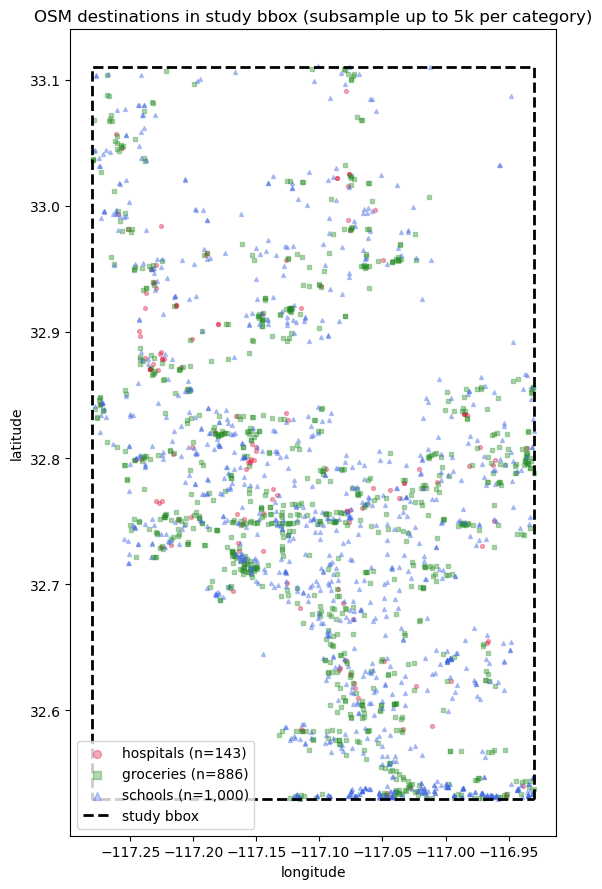

In [9]:
tr_path = ART_TABLES / f"eda__lodes_wac_sd_tract_jobs__{TODAY}.csv"
if tr_path.exists() and "jobs" in OPPORTUNITIES:
    tj = pd.read_csv(tr_path, dtype={"GEOID": str})
    plot_t = tracts_sd.merge(tj, on="GEOID", how="left")
    plot_t["lodes_jobs"] = plot_t["lodes_jobs"].fillna(0)
    fig, ax = plt.subplots(figsize=(9, 9))
    plot_t.plot(
        column="lodes_jobs",
        ax=ax,
        legend=True,
        cmap="YlOrRd",
        edgecolor="0.35",
        linewidth=0.12,
        legend_kwds={"label": "LODES jobs (tract total)", "shrink": 0.6},
        missing_kwds={"color": "whitesmoke"},
    )
    bbox_gdf.boundary.plot(ax=ax, color="navy", linewidth=2, linestyle="--", label="study bbox")
    ax.set_title("LODES WAC jobs by census tract (San Diego County)")
    ax.legend(loc="lower left")
    plt.tight_layout()
    fpj = ART_FIG / f"eda__lodes_wac_sd_tract_jobs_choropleth__{TODAY}.png"
    fig.savefig(fpj, dpi=200, bbox_inches="tight")
    print(f"Saved: {fpj.relative_to(REPO_ROOT)}")
    plt.show()
else:
    print("Skip jobs choropleth: no tract jobs table for this run.")

fig2, ax2 = plt.subplots(figsize=(9, 9))
colors = {"hospitals": "crimson", "groceries": "forestgreen", "schools": "royalblue"}
markers = {"hospitals": "o", "groceries": "s", "schools": "^"}
plotted = False
for key, gdf in poi_tables.items():
    if gdf is None or gdf.empty:
        continue
    g = gdf.to_crs(4326)
    sub = g.sample(min(5000, len(g)), random_state=42) if len(g) > 5000 else g
    x = sub.geometry.centroid.x
    y = sub.geometry.centroid.y
    ax2.scatter(
        x,
        y,
        s=8,
        alpha=0.35,
        c=colors.get(key, "gray"),
        marker=markers.get(key, "o"),
        label=f"{key} (n={len(g):,})",
    )
    plotted = True
bbox_gdf.boundary.plot(ax=ax2, color="black", linewidth=2, linestyle="--", label="study bbox")
ax2.set_title("OSM destinations in study bbox (subsample up to 5k per category)")
ax2.set_xlabel("longitude")
ax2.set_ylabel("latitude")
if plotted:
    ax2.legend(loc="lower left", markerscale=2)
ax2.set_aspect("equal", adjustable="box")
plt.tight_layout()
fpo = ART_FIG / f"eda__osm_destinations_map__{TODAY}.png"
fig2.savefig(fpo, dpi=200, bbox_inches="tight")
print(f"Saved: {fpo.relative_to(REPO_ROOT)}")
plt.show()
